In [1]:
# Imports + repo path
from __future__ import annotations

import os
import sys
from argparse import Namespace
from pathlib import Path
from typing import Tuple
import time

import numpy as np
import torch
import yaml
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
from scipy.stats import gaussian_kde

REPO_ROOT = Path.cwd().resolve()
if (REPO_ROOT / 'src').exists():
    sys.path.append(str(REPO_ROOT))
else:
    # If you opened the notebook from a subdir, try to locate repo root.
    for p in Path.cwd().resolve().parents:
        if (p / 'src').exists():
            REPO_ROOT = p
            sys.path.append(str(REPO_ROOT))
            break

from src.model.energy_force_diffusion import EnergyForceDiffusion
from src.utils import dict_to_namespace

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

/home/iwe67/miniforge3/envs/drugflow/lib/python3.11/site-packages/lightning_fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


device: cuda


In [2]:
# Helpers (swiss-roll data, KDE energy, batching, plotting)

def make_swiss_roll_3d(n_samples: int, noise: float, *, seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    t = rng.uniform(1.5 * np.pi, 4.5 * np.pi, size=(n_samples,))
    x = t * np.cos(t)
    z = t * np.sin(t)
    y = rng.uniform(-6.0, 6.0, size=(n_samples,))  # swiss-roll height
    xyz = np.stack([x, y, z], axis=-1)
    xyz = xyz + rng.normal(scale=noise, size=xyz.shape)
    xyz = xyz / 3.0
    return xyz.astype(np.float32)


class SwissRollKDEEnergy:
    def __init__(self, ref_x: np.ndarray, *, bandwidth: float = 0.2):
        if ref_x.ndim != 2 or ref_x.shape[1] != 3:
            raise ValueError(f'ref_x must have shape (N,3); got {ref_x.shape}')
        self.bandwidth = float(bandwidth)
        self._kde = gaussian_kde(ref_x.T, bw_method=self.bandwidth)

    def node_energy(self, x_query: torch.Tensor) -> torch.Tensor:
        if x_query.ndim != 2 or x_query.shape[1] != 3:
            raise ValueError(f'x_query must have shape (N,3); got {tuple(x_query.shape)}')
        x_np = x_query.detach().cpu().numpy().T
        log_p = np.log(self._kde.evaluate(x_np) + 1e-12).astype(np.float32)
        u = (-log_p).reshape(-1, 1)
        return torch.as_tensor(u, device=x_query.device, dtype=x_query.dtype)


def rgba_with_energy_alpha(
    values: np.ndarray,
    *,
    cmap: str = 'viridis',
    alpha_min: float = 0.05,
    alpha_max: float = 0.95,
    invert_alpha: bool = True,
    clip_percentile: float = 99.0,
) -> tuple[np.ndarray, mcolors.Normalize, mcolors.Colormap]:
    """Map values to RGBA with alpha depending on energy.

    Requirement: lower energy should be less transparent (more opaque).
    We implement that by making alpha decrease with normalized energy.
    """
    v = np.asarray(values, dtype=np.float32).reshape(-1)
    if v.size == 0:
        norm = mcolors.Normalize(vmin=0.0, vmax=1.0)
        cmap_obj = cm.get_cmap(cmap)
        return np.zeros((0, 4), dtype=np.float32), norm, cmap_obj

    v_clip = v.copy()
    if clip_percentile is not None:
        vmax_clip = float(np.percentile(v_clip, float(clip_percentile)))
        v_clip = np.clip(v_clip, a_min=None, a_max=vmax_clip)

    vmin = float(v_clip.min())
    vmax = float(v_clip.max())
    if not (vmax > vmin):
        vmax = vmin + 1e-6

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap_obj = cm.get_cmap(cmap)
    t = norm(v_clip)
    colors = cmap_obj(t)

    a0 = float(alpha_min)
    a1 = float(alpha_max)
    if invert_alpha:
        alpha = a0 + (1.0 - t) * (a1 - a0)
    else:
        alpha = a0 + t * (a1 - a0)
    colors[:, 3] = np.clip(alpha, 0.0, 1.0)
    return colors, norm, cmap_obj


def build_grid_xyz(*, grid_size: int, grid_limit: float) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    g = int(grid_size)
    lim = float(grid_limit)
    xs = np.linspace(-lim, lim, g, dtype=np.float32)
    ys = np.linspace(-lim, lim, g, dtype=np.float32)
    zs = np.linspace(-lim, lim, g, dtype=np.float32)
    xx, yy, zz = np.meshgrid(xs, ys, zs, indexing='xy')
    xyz = np.stack([xx.reshape(-1), yy.reshape(-1), zz.reshape(-1)], axis=-1)
    return xyz, xx, yy, zz


def make_ligand_from_points(
    *,
    xyz: torch.Tensor,             # (N,3)
    t_batch_size: int,             # B (number of graphs)
    atom_nf: int,
    carbon_idx: int,
    device: torch.device,
) -> dict:
    # Each point becomes a 1-node graph.
    N = int(xyz.shape[0])
    if N != t_batch_size:
        raise ValueError(f'Expected N==B for 1-node graphs; got N={N}, B={t_batch_size}')
    pos = xyz.to(device=device, dtype=torch.float32)
    one_hot = torch.zeros((N, atom_nf), device=device, dtype=torch.float32)
    one_hot[:, carbon_idx] = 1.0
    mask = torch.arange(N, device=device, dtype=torch.long)  # graph id per node
    sizes = torch.ones((N,), device=device, dtype=torch.long)
    return {'x': pos, 'one_hot': one_hot, 'mask': mask, 'size': sizes}


@torch.no_grad()
def predict_energy_grid(
    model: EnergyForceDiffusion,
    *,
    xyz_grid: torch.Tensor,    # (N,3)
    grid_size: int,
    allowed_z: list[int],
    t_val: float,
    temperature: float,
) -> np.ndarray:
    # Predict per-point energy by treating each point as a 1-node graph.
    N = int(xyz_grid.shape[0])
    atom_nf = len(allowed_z)
    carbon_idx = allowed_z.index(6) if 6 in allowed_z else 0
    ligand = make_ligand_from_points(
        xyz=xyz_grid,
        t_batch_size=N,
        atom_nf=atom_nf,
        carbon_idx=carbon_idx,
        device=xyz_grid.device,
    )
    t = torch.full((N, 1), float(t_val), device=xyz_grid.device, dtype=torch.float32)
    if model.use_temperature:
        temp = torch.full((N, 1), float(temperature), device=xyz_grid.device, dtype=torch.float32)
    else:
        temp = None
    pred, _ = model.dynamics(
        ligand['x'],
        ligand['one_hot'],
        ligand['mask'],
        pocket=None,
        t=t,
        temperature=temp,
        bonds_ligand=None,
        sc_transform=None,
    )
    e = pred['energy'].detach().cpu().numpy().reshape(grid_size, grid_size, grid_size)
    return e


def plot_loss_curve(loss_history: list[float]):
    fig, ax = plt.subplots(1, 1, figsize=(7, 4), dpi=120)
    ax.plot(loss_history)
    ax.set_title('Loss curve')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.grid(True, alpha=0.2)
    plt.show()

In [3]:
# Config (hardcoded here for easy editing)
##
# Edit ANY setting by modifying the YAML string below.
# This replaces reading from `configs/training/energy_force_qm9_curated.yml`.

CONFIG_YAML = r"""
run_name: energy_force_qm9_curated_fcgraph_ve_hjb_training
model_type: energy_force_diffusion

# Required by src/train.py even if unused by EnergyForceDiffusion
pocket_representation: CA+
virtual_nodes: null
flexible: False
flexible_bb: False

autoregressive: False

dpo_mode: null

train_params:
  logdir: ./runs
  # QM9-curated-style PKL folder (adjust if needed)
  datadir: /home/iwe67/qm_dataset
  enable_progress_bar: True
  num_sanity_val_steps: 0

  batch_size: 64
  accumulate_grad_batches: 2
  lr: 5.0e-3
  n_epochs: 1000
  num_workers: 0
  gpus: 1
  clip_grad: True
  gradient_clip_val: 1.0

  # Debugging: log t/sigma statistics to WandB.
  log_diffusion_stats: False

  # PKL schema keys
  pkl_pos_key: pos
  pkl_atom_types_key: atomic_numbers
  pkl_energy_key: e_total
  pkl_forces_key: forces
  pkl_atom_types_format: atomic_numbers

  # Elements (for this toy: single element)
  pkl_allowed_atomic_numbers: [6]

  # Flat-dir deterministic split
  pkl_val_fraction: 0.01
  pkl_val_n: null
  pkl_split_seed: 42

  # Optional: limit files for debugging, for full dataset use null
  pkl_file_limit: null

wandb_params:
  mode: offline  # disabled, offline, online
  entity:
  group: qm9_curated

loss_params:
  discrete_loss: CE  # CE or VLB

  # Loss weights
  lambda_x: 0.0
  lambda_h: 0.0
  lambda_energy: 2.0

  # New: energy gauge regularizer (encourage u(x,t=0) ≈ 0). Default 0.0 (off).
  lambda_energy_t0: 0.0

  # Continuity equation loss (repo convention: t=0 noisy -> t=1 clean)
  lambda_hjb: 1.0
  # Constitutive relation loss
  lambda_consistency: 1.0

  # (Legacy score-matching knobs; unused for flow-matching coordinate training)
  x_score_weight_by_sigma: True
  use_min_snr: True
  min_snr_gamma: 5.0

  # Divergence estimator for div(v):
  #   - hutchinson: memory-efficient stochastic trace estimator (recommended)
  #   - exact: exact trace(dv/dx) (very memory-heavy)
  hjb_divergence: exact
  hjb_trace_samples: 2
  # If false, computes PDE terms without enabling higher-order gradients (useful for logging only).
  hjb_enable_higher_order: True
  hjb_divergence_create_graph: True
  hjb_trace_batch_size: 1
  hjb_debug: True
  reduce: mean

simulation_params:
  n_steps: 1000

  # IMPORTANT for this toy notebook: we want the energy to depend on ABSOLUTE position (x,y,z).
  # Molecular training usually enforces translation invariance by centering; for 1-node graphs
  # that would collapse all inputs to zero and make learning impossible.
  center_ligand: False

  enforce_zero_com_noise: False
  project_predicted_v_zero_com: False
  diffuse_h: False

  # Score diffusion noise schedule for coordinates (t=0 noise -> t=1 clean)
  sigma_min: 0.01
  sigma_max: 5.0
  coord_sde_kind: ve

  # Temperature conditioning
  use_temperature: False
  temperature: 1.0
  temperature_min: 1.0
  temperature_max: 1.0

eval_params:
  eval_batch_size: 64
  eval_epochs: 1
  n_loss_per_sample: 1

predictor_params:
  # Pure MLP ScoreNet (no GNN).
  backbone: scorenet_mlp

  # Conditioning
  condition_time: True
  condition_temperature: False

  scorenet_mlp:
    hidden_dim: 128
    time_emb_dim: 64
    num_layers: 4
"""

cfg_raw = yaml.safe_load(CONFIG_YAML)
cfg = {k: dict_to_namespace(v) for k, v in cfg_raw.items()}

model = EnergyForceDiffusion(
    pocket_representation=str(cfg['pocket_representation']),
    train_params=cfg['train_params'],
    loss_params=cfg['loss_params'],
    eval_params=cfg.get('eval_params', Namespace()),
    predictor_params=cfg['predictor_params'],
    simulation_params=cfg['simulation_params'],
    virtual_nodes=cfg.get('virtual_nodes', None),
    flexible=bool(cfg.get('flexible', False)),
    flexible_bb=bool(cfg.get('flexible_bb', False)),
    debug=False,
    overfit=False,
).to(device)

model.train()

lr = float(getattr(cfg['train_params'], 'lr', 5e-4))
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, amsgrad=True, weight_decay=1e-12)

print('Model built. use_temperature=', model.use_temperature, 'backbone=', cfg['predictor_params'].backbone)
print('center_ligand=', bool(getattr(cfg['simulation_params'], 'center_ligand', True)))
print('project_predicted_v_zero_com=', bool(getattr(cfg['simulation_params'], 'project_predicted_v_zero_com', False)))


Model built. use_temperature= False backbone= scorenet_mlp
center_ligand= False
project_predicted_v_zero_com= False


In [4]:
# Target landscape + grid
n_ref = 2000
noise = 0.1
bandwidth = 0.2
ref = make_swiss_roll_3d(n_ref, noise, seed=0)
target_landscape = SwissRollKDEEnergy(ref, bandwidth=bandwidth)

grid_size = 18
grid_limit = 4.0
grid_xyz_np, xx, yy, zz = build_grid_xyz(grid_size=grid_size, grid_limit=grid_limit)
grid_tensor = torch.as_tensor(grid_xyz_np, device=device, dtype=torch.float32)

# Precompute target energy on the grid (t-independent here)
u_true_grid = target_landscape.node_energy(grid_tensor).detach().cpu().numpy().reshape(grid_size, grid_size, grid_size)
print('grid N:', grid_tensor.shape[0])

grid N: 5832


/tmp/ipykernel_178112/848023484.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = cm.get_cmap(cmap)


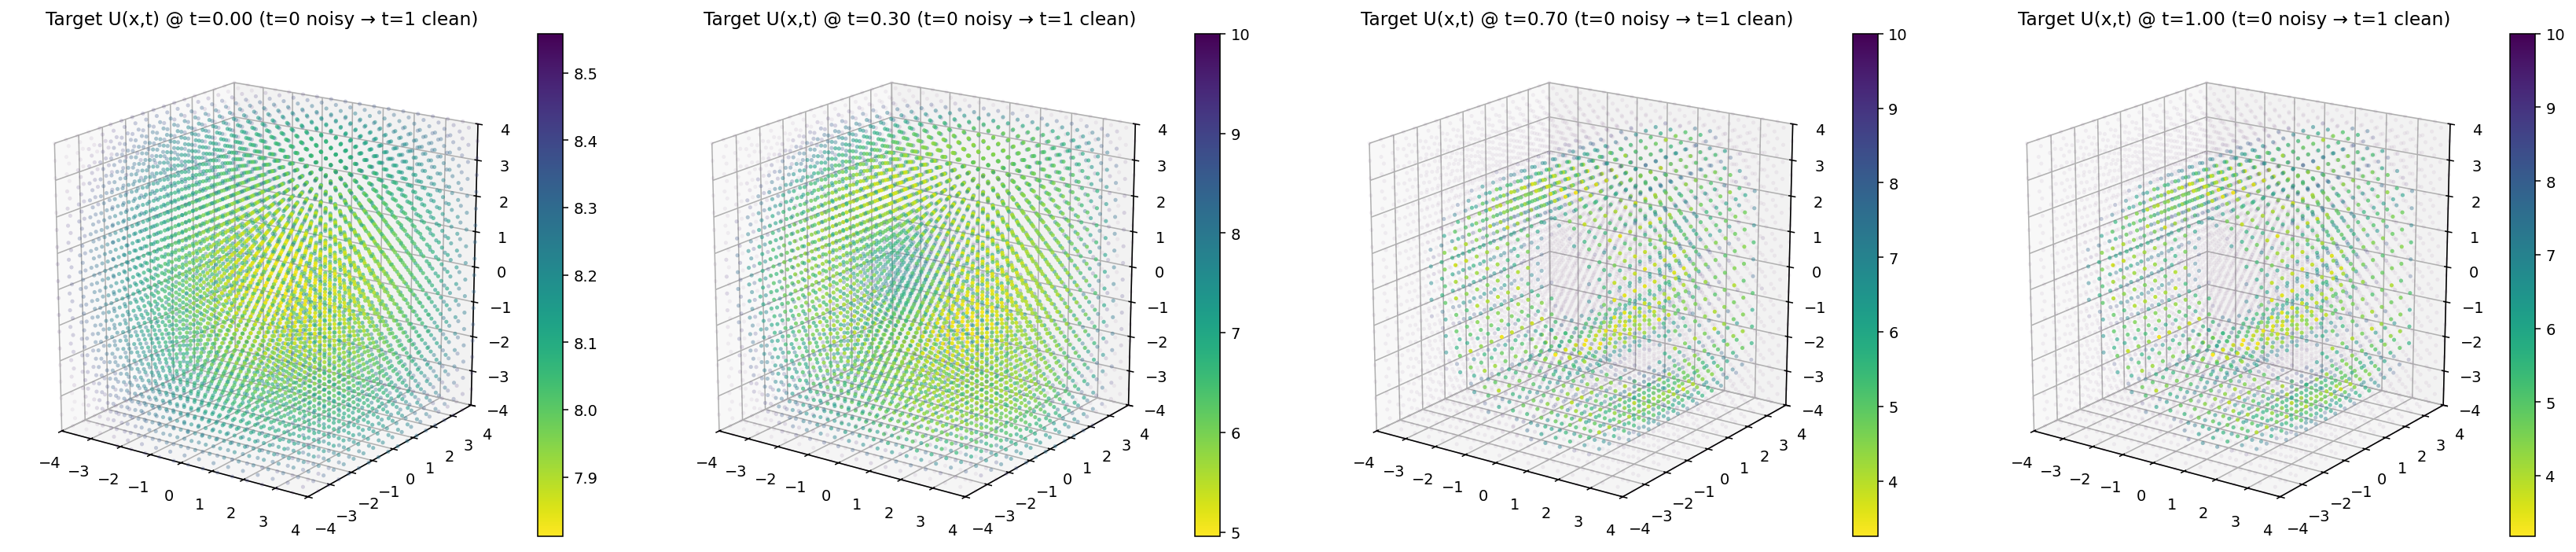

In [5]:
# --- Visualize target energy landscape at multiple smoothing steps (diffusion time) ---
#
# DrugFlow time convention: t=0 is *max noise* (most smoothed), t=1 is *clean* (least smoothed).
# We build a time-dependent KDE snapshot by:
#   centers(t) = alpha(t) * centers(clean)
#   bw(t)^2    = (alpha(t) * bw0)^2 + (sigma(t)^2 - sigma(1)^2)
# using the same (VE/VP) schedule as `model.module_x`.

@torch.no_grad()
def gaussian_mixture_energy_3d(
    x_query: torch.Tensor,          # (M,3)
    centers: torch.Tensor,          # (N,3)
    *,
    bandwidth: float,
) -> torch.Tensor:
    """Negative log KDE density for an isotropic Gaussian mixture."""
    if x_query.ndim != 2 or x_query.shape[1] != 3:
        raise ValueError(f"x_query must have shape (M,3); got {tuple(x_query.shape)}")
    if centers.ndim != 2 or centers.shape[1] != 3:
        raise ValueError(f"centers must have shape (N,3); got {tuple(centers.shape)}")

    bw = float(bandwidth)
    if not (bw > 0.0):
        raise ValueError(f"bandwidth must be positive; got {bw}")

    x = x_query[:, None, :]              # (M,1,3)
    c = centers[None, :, :]              # (1,N,3)
    d2 = torch.sum((x - c) ** 2, dim=-1) # (M,N)

    # log p(x) = log(1/N * sum_i exp(-||x-c_i||^2/(2 bw^2))) + const
    log_k = -0.5 * d2 / (bw * bw)
    # 3D isotropic Gaussian: (2π bw^2)^{3/2}
    log_norm = -np.log(centers.shape[0]) - 1.5 * np.log(2.0 * np.pi * bw * bw)
    log_p = torch.logsumexp(log_k, dim=1) + float(log_norm)
    return (-log_p).reshape(-1, 1)


@torch.no_grad()
def target_energy_grid_at_t(*, t_val: float, clip_max: float | None = None) -> np.ndarray:
    """Return the time-dependent target energy grid U_true(x,t) as (g,g,g)."""
    if 'ref' not in globals():
        raise RuntimeError("`ref` not found. Run Cell 4 first.")
    centers_clean = torch.as_tensor(ref, device=device, dtype=torch.float32)
    bw0 = float(bandwidth)

    t_tensor = torch.as_tensor([[float(t_val)]], device=device, dtype=torch.float32)
    alpha_t = float(model.module_x.alpha(t_tensor).view(-1)[0].item())
    sigma_t = float(model.module_x.sigma(t_tensor).view(-1)[0].item())
    sigma_clean = float(model.module_x.sigma(torch.ones((1, 1), device=device, dtype=torch.float32)).view(-1)[0].item())

    var_added = max(0.0, sigma_t * sigma_t - sigma_clean * sigma_clean)
    bw_t = float(np.sqrt((alpha_t * bw0) ** 2 + var_added))
    centers_t = centers_clean * float(alpha_t)

    u = gaussian_mixture_energy_3d(grid_tensor, centers_t, bandwidth=bw_t)
    u_np = u.detach().cpu().numpy().reshape(grid_size, grid_size, grid_size)
    if clip_max is not None:
        u_np = np.clip(u_np, a_min=None, a_max=float(clip_max))
    return u_np


@torch.no_grad()
def plot_target_energy_smoothing(*, times: list[float], clip_max: float = 10.0):
    fig = plt.figure(figsize=(6 * len(times), 5), dpi=140)
    axes = [fig.add_subplot(1, len(times), i + 1, projection='3d') for i in range(len(times))]

    for ax, t_val in zip(axes, times):
        u_np = target_energy_grid_at_t(t_val=float(t_val), clip_max=clip_max).reshape(-1)
        colors, norm, cmap_obj = rgba_with_energy_alpha(
            u_np,
            cmap='viridis_r',
            alpha_min=0.05,
            alpha_max=0.98,
            invert_alpha=True,
            clip_percentile=99.0,
        )
        ax.scatter(
            grid_xyz_np[:, 0],
            grid_xyz_np[:, 1],
            grid_xyz_np[:, 2],
            c=colors,
            s=7,
            linewidths=0,
            depthshade=False,
        )
        # IMPORTANT: `ref` is the clean data distribution; only overlay it at t=1.0.
        if abs(float(t_val) - 1.0) < 1e-6:
            ax.scatter(ref[:, 0], ref[:, 1], ref[:, 2], s=1, c='white', alpha=0.12, linewidths=0)

        ax.set_title(f"Target U(x,t) @ t={t_val:.2f} (t=0 noisy → t=1 clean)")
        ax.set_xlim(-grid_limit, grid_limit)
        ax.set_ylim(-grid_limit, grid_limit)
        ax.set_zlim(-grid_limit, grid_limit)
        if hasattr(ax, 'set_box_aspect'):
            ax.set_box_aspect((1, 1, 1))
        ax.view_init(elev=18, azim=-55)
        mappable = cm.ScalarMappable(norm=norm, cmap=cmap_obj)
        mappable.set_array(u_np)
        fig.colorbar(mappable, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


# Pick the same times you use later for learned-energy plots.
# Reminder: smaller t -> more noise -> smoother target.
target_times = [0.0, 0.3, 0.7, 1.0]
plot_target_energy_smoothing(times=target_times, clip_max=10.0)


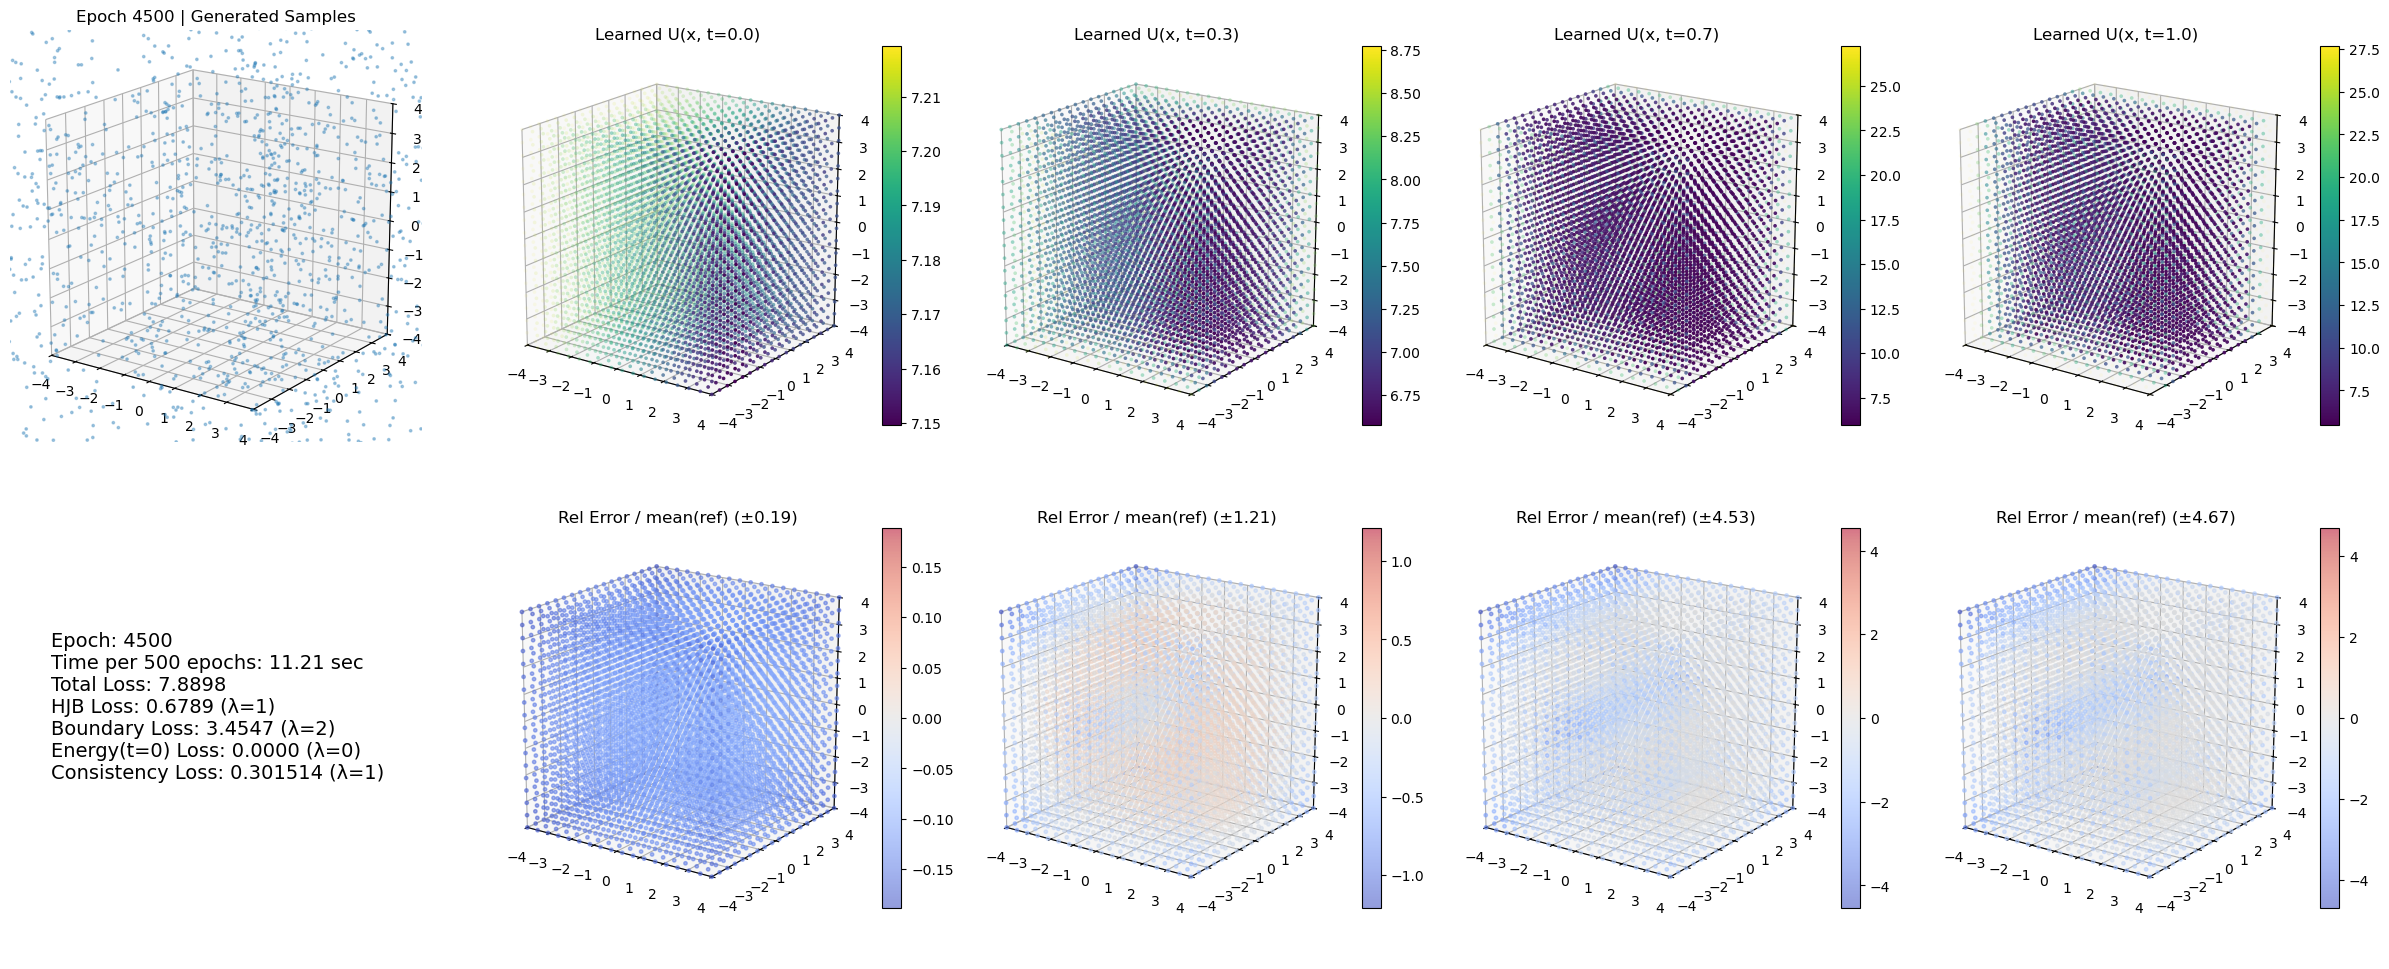

Epoch 4500 | Loss: 7.8898


KeyboardInterrupt: 

In [8]:
# --- Training loop with live plotting (matches the 2D notebook logic, but stays fully 3D) ---
num_epochs = 5000
batch_size = 512      # number of 1-node graphs per step
lambda_hjb = float(cfg['loss_params'].lambda_hjb)
lambda_cons = float(cfg['loss_params'].lambda_consistency)
lambda_bound = float(cfg['loss_params'].lambda_energy)
lambda_energy_t0 = float(getattr(cfg['loss_params'], 'lambda_energy_t0', 0.0))
lambda_x = float(cfg['loss_params'].lambda_x)

times_to_plot = [0.0, 0.3, 0.7, 1.0]
titles = ['t=0.0', 't=0.3', 't=0.7', 't=1.0']
plot_every = 500
loss_history = []
loss_hjb_hist = []
loss_cons_hist = []
loss_bound_hist = []
loss_energy_t0_hist = []

epoch_time = 0.0
n_epochs_times = []

allowed_z = list(getattr(cfg['train_params'], 'pkl_allowed_atomic_numbers', [1, 6, 7, 8, 9]))
atom_nf = len(allowed_z)
carbon_idx = allowed_z.index(6) if 6 in allowed_z else 0

# If we're training with the denoising score matching loss (lambda_x > 0),
# then `ligand['x']` must be drawn from the true data distribution (swiss roll).
# Otherwise, keep the original uniform collocation sampling behavior unchanged.
use_denoising_loss = (lambda_x > 0.0)
ref_tensor = None
if use_denoising_loss:
    if 'ref' not in globals():
        raise RuntimeError("`ref` not found. Run Cell 4 (Target landscape + grid) before training.")
    ref_tensor = torch.as_tensor(ref, device=device, dtype=torch.float32)  # (N_ref, 3)

print('--- Starting 3D HJB Training (Swiss Roll) ---')
for epoch in range(num_epochs):
    start_time = time.time()
    optimizer.zero_grad(set_to_none=True)

    # 1) Sample clean points x from data distribution if denoising loss is active, else uniform collocation points.
    if use_denoising_loss:
        assert ref_tensor is not None
        idx = torch.randint(0, ref_tensor.shape[0], (batch_size,), device=device)
        x_train = ref_tensor[idx]  # (B,3) swiss-roll samples
    else:
        x_train = (torch.rand(batch_size, 3, device=device) * 8.0) - 4.0  # uniform in [-4,4]^3

    t_train = torch.rand(batch_size, 1, device=device)

    # 2) Uniform temperature per example (requires conditioning enabled)
    if model.use_temperature:
        temperature_train = torch.empty(batch_size, 1, device=device).uniform_(
            float(cfg['simulation_params'].temperature_min),
            float(cfg['simulation_params'].temperature_max),
        )
    else:
        temperature_train = None

    # 3) Build ligand batch: each point is a 1-node graph
    ligand = make_ligand_from_points(
        xyz=x_train,
        t_batch_size=batch_size,
        atom_nf=atom_nf,
        carbon_idx=carbon_idx,
        device=device,
    )

    # 4) Boundary energy target per-graph (each graph is a single node)
    # NOTE: For plotting we use a time-dependent target surface; training still uses this KDE energy helper.
    energy_tgt = target_landscape.node_energy(x_train).view(-1)  # (B,)

    # 5) Compute repo loss (includes boundary + HJB + consistency)
    loss, info = model.compute_loss(
        ligand,
        energy=energy_tgt,
        t=t_train,
        temperature=temperature_train,
        return_info=True,
    )

    loss_history.append(float(loss.detach().cpu().item()))
    loss_hjb_hist.append(float(info.get('loss_hjb', 0.0)))
    loss_cons_hist.append(float(info.get('loss_consistency', 0.0)))
    loss_bound_hist.append(float(info.get('loss_energy', 0.0)))
    loss_energy_t0_hist.append(float(info.get('loss_energy_t0', 0.0)))

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    end_time = time.time()
    epoch_time = epoch_time + (end_time - start_time)

    if (epoch % plot_every) == 0:
        clear_output(wait=True)
        n_epochs_times.append(epoch_time)

        fig = plt.figure(figsize=(24, 10))
        gs = fig.add_gridspec(2, 1 + len(times_to_plot))
        ax_samples = fig.add_subplot(gs[0, 0], projection='3d')
        ax_text = fig.add_subplot(gs[1, 0])
        axes_energy = [fig.add_subplot(gs[0, i + 1], projection='3d') for i in range(len(times_to_plot))]
        axes_err = [fig.add_subplot(gs[1, i + 1], projection='3d') for i in range(len(times_to_plot))]

        # A) Samples (Top-Left)
        model.eval()
        samp = model.sample_ligand(
            n_samples=2000,
            num_nodes=1,
            temperature=1.0,
            x_sampler='ode',
            h_sampler='markov_bridge',
            stochastic_x=False,
            stochastic_h=False,
        )
        samples_xyz = samp['x'][:, 0:3].detach().cpu().numpy()
        ax_samples.scatter(samples_xyz[:, 0], samples_xyz[:, 1], samples_xyz[:, 2], s=3, alpha=0.35)
        ax_samples.set_title(f'Epoch {epoch} | Generated Samples')
        ax_samples.set_xlim(-4, 4)
        ax_samples.set_ylim(-4, 4)
        ax_samples.set_zlim(-4, 4)
        if hasattr(ax_samples, 'set_box_aspect'):
            ax_samples.set_box_aspect((1, 1, 1))
        ax_samples.view_init(elev=18, azim=-55)

        # B) Loss text (Bottom-Left)
        ax_text.axis('off')
        avg_time = float(np.mean(n_epochs_times[1:])) if len(n_epochs_times) > 1 else float('nan')
        info_text = (
            f'Epoch: {epoch}\n'
            f'Time per {plot_every} epochs: {avg_time:.2f} sec\n'
            f'Total Loss: {loss_history[-1]:.4f}\n'
            f'HJB Loss: {loss_hjb_hist[-1]:.4f} (λ={lambda_hjb:g})\n'
            f'Boundary Loss: {loss_bound_hist[-1]:.4f} (λ={lambda_bound:g})\n'
            f'Energy(t=0) Loss: {loss_energy_t0_hist[-1]:.4f} (λ={lambda_energy_t0:g})\n'
            f'Consistency Loss: {loss_cons_hist[-1]:.6f} (λ={lambda_cons:g})\n'
        )
        ax_text.text(0.1, 0.5, info_text, fontsize=14, va='center')

        # Pre-calc learned energies and diffs.
        # IMPORTANT: compare to the time-dependent target surface U_true(x,t_val), not always the t=1 surface.
        plot_data = []
        diffs = []
        for t_val in times_to_plot:
            u_learned = predict_energy_grid(
                model,
                xyz_grid=grid_tensor,
                grid_size=grid_size,
                allowed_z=allowed_z,
                t_val=float(t_val),
                temperature=1.0,
            )
            u_true = target_energy_grid_at_t(t_val=float(t_val), clip_max=None)
            u_diff = (u_learned - u_true) / float(np.mean(u_true))
            plot_data.append((u_learned, u_diff))
            diffs.append(u_diff)

        # C) Plot learned energy (top row) + error (bottom row)
        for i, (u_learned_np, u_diff_np) in enumerate(plot_data):
            ax_u = axes_energy[i]
            ax_e = axes_err[i]

            colors_u, norm_u, cmap_u = rgba_with_energy_alpha(
                u_learned_np.reshape(-1),
                cmap='viridis',
                alpha_min=0.05,
                alpha_max=0.98,
                invert_alpha=True,
                clip_percentile=99.0,
            )
            ax_u.scatter(
                grid_xyz_np[:, 0],
                grid_xyz_np[:, 1],
                grid_xyz_np[:, 2],
                c=colors_u,
                s=7,
                linewidths=0,
                depthshade=False,
            )
            ax_u.set_title(f'Learned U(x, {titles[i]})')
            ax_u.set_xlim(-4, 4)
            ax_u.set_ylim(-4, 4)
            ax_u.set_zlim(-4, 4)
            if hasattr(ax_u, 'set_box_aspect'):
                ax_u.set_box_aspect((1, 1, 1))
            ax_u.view_init(elev=18, azim=-55)
            fig.colorbar(cm.ScalarMappable(norm=norm_u, cmap=cmap_u), ax=ax_u, fraction=0.046, pad=0.04)

            # IMPORTANT: `ref` is the clean distribution; only overlay it on the t=1 plot.
            if abs(float(times_to_plot[i]) - 1.0) < 1e-6:
                ax_u.scatter(ref[:500, 0], ref[:500, 1], ref[:500, 2], s=1, c='white', alpha=0.2)

            rel_max_abs_error = float(np.abs(diffs[i]).max())
            if rel_max_abs_error < 1e-3:
                rel_max_abs_error = 0.01

            im2 = ax_e.scatter(
                grid_xyz_np[:, 0],
                grid_xyz_np[:, 1],
                grid_xyz_np[:, 2],
                c=u_diff_np.reshape(-1),
                s=6,
                alpha=0.55,
                cmap='coolwarm',
                vmin=-rel_max_abs_error,
                vmax=rel_max_abs_error,
            )
            ax_e.set_title(f'Rel Error / mean(ref) (±{rel_max_abs_error:.2f})')
            ax_e.set_xlim(-4, 4)
            ax_e.set_ylim(-4, 4)
            ax_e.set_zlim(-4, 4)
            if hasattr(ax_e, 'set_box_aspect'):
                ax_e.set_box_aspect((1, 1, 1))
            ax_e.view_init(elev=18, azim=-55)
            fig.colorbar(im2, ax=ax_e, fraction=0.046, pad=0.04)

        epoch_time = 0.0
        plt.tight_layout()
        display(fig)
        plt.close(fig)
        model.train()
        print(f'Epoch {epoch} | Loss: {loss_history[-1]:.4f}')

print('--- Training Finished ---')
plot_loss_curve(loss_history)

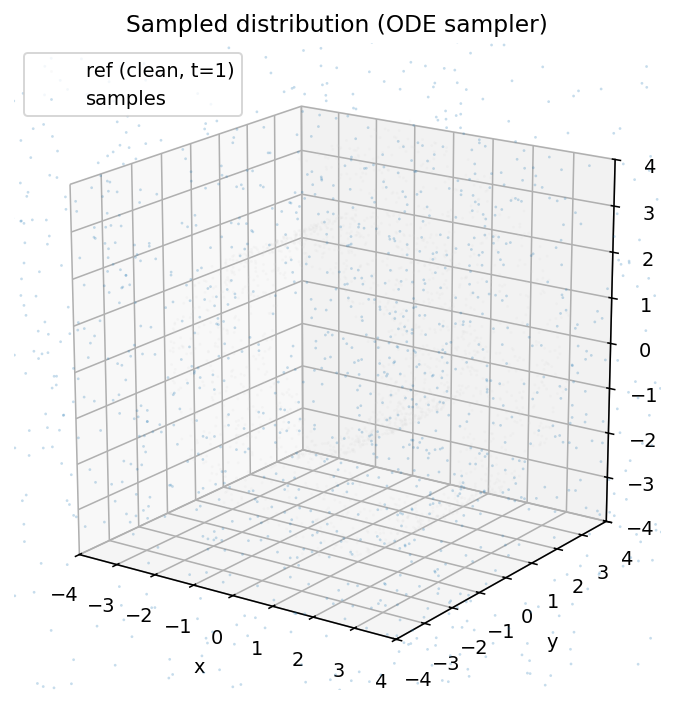

/tmp/ipykernel_177836/848023484.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = cm.get_cmap(cmap)


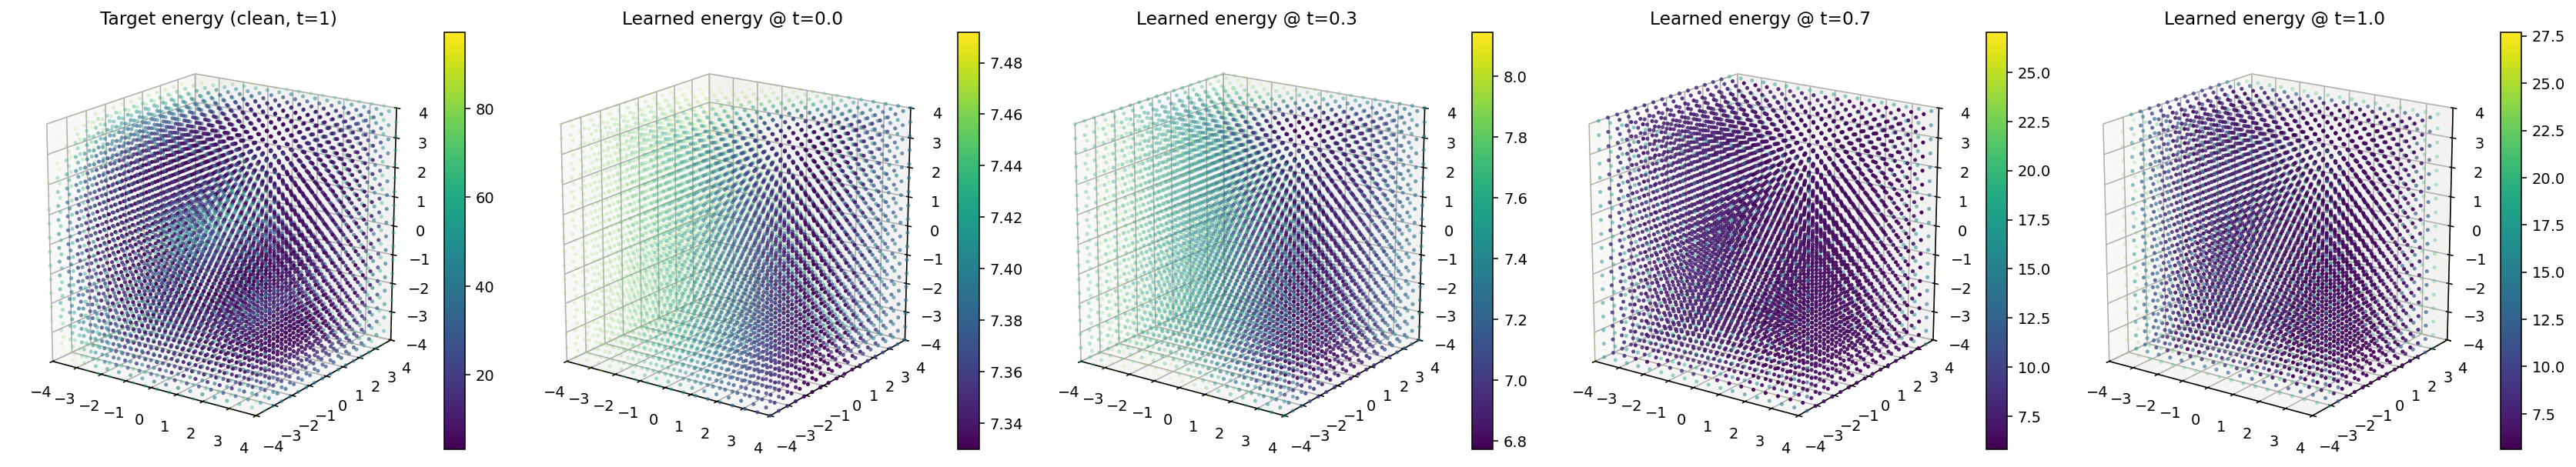

In [ ]:
# Post-training plots: sampled distribution + learned energy surfaces at t={0,0.3,0.7,1}
model.eval()
fig = plt.figure(figsize=(7, 6), dpi=140)
ax = fig.add_subplot(1, 1, 1, projection='3d')
samp = model.sample_ligand(
    n_samples=2000,
    num_nodes=1,
    temperature=1.0,
    x_sampler='ode',
    h_sampler='markov_bridge',
    stochastic_x=False,
    stochastic_h=False,
 )
xyz = samp['x'][:, 0:3].detach().cpu().numpy()
ax.scatter(ref[:, 0], ref[:, 1], ref[:, 2], s=2, c='0.85', alpha=0.14, linewidths=0, label='ref (clean, t=1)')
ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], s=2, alpha=0.25, linewidths=0, label='samples')
ax.set_title('Sampled distribution (ODE sampler)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_zlim(-4, 4)
if hasattr(ax, 'set_box_aspect'):
    ax.set_box_aspect((1, 1, 1))
ax.view_init(elev=18, azim=-55)
ax.legend()
plt.show()

fig = plt.figure(figsize=(24, 5), dpi=140)
axes = [fig.add_subplot(1, 1 + len(times_to_plot), i + 1, projection='3d') for i in range(1 + len(times_to_plot))]

# Target: show clean (t=1) energy surface for reference
u_true_clean = target_energy_grid_at_t(t_val=1.0, clip_max=None)
colors_t, norm_t, cmap_t = rgba_with_energy_alpha(
    u_true_clean.reshape(-1),
    cmap='viridis',
    alpha_min=0.05,
    alpha_max=0.98,
    invert_alpha=True,
    clip_percentile=99.0,
 )
axes[0].scatter(
    grid_xyz_np[:, 0],
    grid_xyz_np[:, 1],
    grid_xyz_np[:, 2],
    c=colors_t,
    s=7,
    linewidths=0,
    depthshade=False,
 )
axes[0].set_title('Target energy (clean, t=1)')
axes[0].set_xlim(-4, 4)
axes[0].set_ylim(-4, 4)
axes[0].set_zlim(-4, 4)
if hasattr(axes[0], 'set_box_aspect'):
    axes[0].set_box_aspect((1, 1, 1))
axes[0].view_init(elev=18, azim=-55)
plt.colorbar(cm.ScalarMappable(norm=norm_t, cmap=cmap_t), ax=axes[0], fraction=0.046, pad=0.04)

for i, t_val in enumerate(times_to_plot):
    u_learned = predict_energy_grid(
        model,
        xyz_grid=grid_tensor,
        grid_size=grid_size,
        allowed_z=allowed_z,
        t_val=float(t_val),
        temperature=1.0,
    )
    colors_l, norm_l, cmap_l = rgba_with_energy_alpha(
        u_learned.reshape(-1),
        cmap='viridis',
        alpha_min=0.05,
        alpha_max=0.98,
        invert_alpha=True,
        clip_percentile=99.0,
    )
    axes[i + 1].scatter(
        grid_xyz_np[:, 0],
        grid_xyz_np[:, 1],
        grid_xyz_np[:, 2],
        c=colors_l,
        s=7,
        linewidths=0,
        depthshade=False,
    )
    axes[i + 1].set_title(f'Learned energy @ t={float(t_val):.1f}')
    axes[i + 1].set_xlim(-4, 4)
    axes[i + 1].set_ylim(-4, 4)
    axes[i + 1].set_zlim(-4, 4)
    if hasattr(axes[i + 1], 'set_box_aspect'):
        axes[i + 1].set_box_aspect((1, 1, 1))
    axes[i + 1].view_init(elev=18, azim=-55)
    plt.colorbar(cm.ScalarMappable(norm=norm_l, cmap=cmap_l), ax=axes[i + 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()